In [26]:
import re, json, math
import pandas as pd
import pyterrier as pt
import random
import matplotlib.pyplot as plt
import os
# -------------------------
# Load Terrier index
# -------------------------
if not pt.java.started():
    pt.java.init()

# testing with example

In [11]:
# index
INDEX_PROPERTIES = "../example/toy/index/pubmed_bm25_example/data.properties"
index = pt.IndexFactory.of(INDEX_PROPERTIES)

bm25 = pt.BatchRetrieve(index, wmodel="BM25")  # you can pass num_results later via slicing

/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_74524/2629605999.py:5: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  bm25 = pt.BatchRetrieve(index, wmodel="BM25")  # you can pass num_results later via slicing


In [12]:
# -------------------------
# Load BioASQ golden file
# -------------------------
GOLD_PATH = "../example/toy/example_query.json"  # adjust if needed

with open(GOLD_PATH, "r", encoding="utf-8") as f:
    gold = json.load(f)

questions = gold["questions"]

def url_to_pmid(url: str) -> str | None:
    m = re.search(r"pubmed/(\d+)", url)
    return m.group(1) if m else None

topics = []
gold_map = {}  # qid -> set(docno=pmid)
for q in questions:
    qid = str(q["id"])
    query = q["body"]
    topics.append({"qid": qid, "query": query})

    pmids = set()
    for u in q.get("documents", []):
        pmid = url_to_pmid(u)
        if pmid:
            pmids.add(pmid)
    gold_map[qid] = pmids

topics_df = pd.DataFrame(topics)

print("n_questions:", len(topics_df))
print("example q:", topics_df.iloc[0].to_dict())
print("example gold docnos:", list(gold_map[topics_df.iloc[0]["qid"]])[:5])

n_questions: 2
example q: {'qid': 'toy_0001', 'query': 'Which ginsenoside C-20 epimer shows a stereoselective promoting effect on ADP-induced platelet aggregation via the platelet P2Y12 receptor, and what molecular interaction is implicated?'}
example gold docnos: ['31454649']


In [13]:
topics_df

,qid,query
0,toy_0001,Which ginsenoside C-20 epimer shows a stereose...
1,toy_0002,"In hemodialysis patients, how can convolutiona..."


In [14]:
# -------------------------
# BioASQ-style eval helpers (from your notebook)
# -------------------------
def ap_bioasq(ranked: list[str], relset: set[str], k: int = 10) -> float:
    ranked = ranked[:k]
    if not relset:
        return 0.0
    denom = min(len(relset), k)
    if denom == 0:
        return 0.0
    hits = 0
    s = 0.0
    for i, docno in enumerate(ranked, start=1):
        if docno in relset:
            hits += 1
            s += hits / i
    return s / denom

def rr_at_k(ranked: list[str], relset: set[str], k: int = 10) -> float:
    ranked = ranked[:k]
    for i, docno in enumerate(ranked, start=1):
        if docno in relset:
            return 1.0 / i
    return 0.0

def success_at_k(ranked: list[str], relset: set[str], k: int = 10) -> int:
    ranked = ranked[:k]
    return int(any(docno in relset for docno in ranked))

def recall_at_k(ranked: list[str], relset: set[str], k: int) -> float:
    ranked = ranked[:k]
    if not relset:
        return 0.0
    return len(set(ranked) & relset) / len(relset)

def evaluate_run(gold_map: dict[str, set[str]],
                 run_map: dict[str, list[str]],
                 ks_recall=(50, 100, 200, 500),
                 eps=1e-5):
    perq = []
    APs, RRs, S10s = [], [], []
    recalls = {K: [] for K in ks_recall}

    for qid, relset in gold_map.items():
        ranked = run_map.get(qid, [])

        ap = ap_bioasq(ranked, relset, k=10)
        rr = rr_at_k(ranked, relset, k=10)
        s10 = success_at_k(ranked, relset, k=10)

        APs.append(ap); RRs.append(rr); S10s.append(s10)

        rec_k_vals = {}
        for K in ks_recall:
            rK = recall_at_k(ranked, relset, k=K)
            recalls[K].append(rK)
            rec_k_vals[f"R@{K}"] = rK

        perq.append({
            "qid": qid,
            "n_gold": len(relset),
            "AP@10": ap,
            "RR@10": rr,
            "Success@10": s10,
            **rec_k_vals
        })

    MAP10 = sum(APs) / len(APs) if APs else 0.0
    GMAP10 = math.exp(sum(math.log(a + eps) for a in APs) / len(APs)) if APs else 0.0
    MRR10 = sum(RRs) / len(RRs) if RRs else 0.0
    Success10 = sum(S10s) / len(S10s) if S10s else 0.0
    RecallK = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls.items()}

    summary = {
        "MAP@10": MAP10,
        "GMAP@10": GMAP10,
        "MRR@10": MRR10,
        "Success@10": Success10,
        **{f"MeanR@{K}": v for K, v in RecallK.items()}
    }
    perq_df = pd.DataFrame(perq).sort_values("qid")
    return summary, perq_df

In [15]:
# -------------------------
# Run BM25 and build run_map
# -------------------------
K_MAX = 500  # overfetch for recall@K; eval AP@10 still uses top 10
res = bm25.transform(topics_df)

# sort by score desc within qid, add rank, cut at K_MAX
res = res.sort_values(["qid", "score"], ascending=[True, False])
res["rank"] = res.groupby("qid").cumcount() + 1
res = res[res["rank"] <= K_MAX].copy()

run_map = {qid: grp["docno"].astype(str).tolist()
           for qid, grp in res.groupby("qid", sort=False)}

summary, perq_df = evaluate_run(gold_map, run_map, ks_recall=(50,100,200,500), eps=1e-5)
print(summary)
perq_df.head()

{'MAP@10': 1.0, 'GMAP@10': 1.00001, 'MRR@10': 1.0, 'Success@10': 1.0, 'MeanR@50': 1.0, 'MeanR@100': 1.0, 'MeanR@200': 1.0, 'MeanR@500': 1.0}


,qid,n_gold,AP@10,RR@10,Success@10,R@50,R@100,R@200,R@500
0,toy_0001,1,1.0,1.0,1,1.0,1.0,1.0,1.0
1,toy_0002,1,1.0,1.0,1,1.0,1.0,1.0,1.0


# after indexing 2025 baseline

In [18]:
index = pt.IndexFactory.of("/Users/yun/develop/pubmed_bm25_index/data.properties")
coll = index.getCollectionStatistics()

print("Number of documents:", coll.getNumberOfDocuments())
print("Number of tokens:", coll.getNumberOfTokens())
print("Number of unique terms:", coll.getNumberOfUniqueTerms())
print("Avg doc length:", coll.getAverageDocumentLength())

14:55:23.467 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading lookup file directly from disk (SLOW) - try index.meta.index-source=fileinmem in the index properties file. 204 MiB of memory would be required.
14:55:23.469 [main] WARN org.terrier.structures.BaseCompressingMetaIndex -- Structure meta reading data file directly from disk (SLOW) - try index.meta.data-source=fileinmem in the index properties file. 606.9 MiB of memory would be required.
Number of documents: 26744845
Number of tokens: 3676162772
Number of unique terms: 4432868
Avg doc length: 137.45313431429497


# Evaluate with BioASQ Training13b data

In [40]:
# Load BioASQ training13b data
TRAIN_PATH = "/Users/yun/develop/BioASQ/BioASQ-training13b/training13b.json"

with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    train_data = json.load(f)

train_questions = train_data["questions"]

# Build topics and gold_map for training data
train_topics = []
train_gold_map = {}

for q in train_questions:
    qid = str(q["id"])
    query = q["body"]
    train_topics.append({"qid": qid, "query": query})

    pmids = set()
    for u in q.get("documents", []):
        pmid = url_to_pmid(u)
        if pmid:
            pmids.add(pmid)
    train_gold_map[qid] = pmids

train_topics_df = pd.DataFrame(train_topics)

print("n_questions:", len(train_topics_df))
print("example q:", train_topics_df.iloc[0].to_dict())
print("example gold docnos:", list(train_gold_map[train_topics_df.iloc[0]["qid"]])[:5])

n_questions: 5389
example q: {'qid': '55031181e9bde69634000014', 'query': 'Is Hirschsprung disease a mendelian or a multifactorial disorder?'}
example gold docnos: ['21995290', '20598273', '6650562', '15858239', '23001136']


In [41]:
# Run BM25 with full 2025 baseline index
bm25_full = pt.BatchRetrieve(index, wmodel="BM25")

K_MAX = 2000
train_res_raw = bm25_full.transform(train_topics_df)

# Sort and rank
train_res_raw = train_res_raw.sort_values(["qid", "score"], ascending=[True, False])
train_res_raw["rank"] = train_res_raw.groupby("qid").cumcount() + 1

/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_74524/769170807.py:2: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  bm25_full = pt.BatchRetrieve(index, wmodel="BM25")


In [42]:
train_res = train_res_raw[train_res_raw["rank"] <= K_MAX].copy()

train_run_map = {qid: grp["docno"].astype(str).tolist()
                 for qid, grp in train_res.groupby("qid", sort=False)}

# Evaluate
train_summary, train_perq_df = evaluate_run(train_gold_map, train_run_map, ks_recall=(50,100,200,500,2000), eps=1e-5)

print("Training13b Evaluation Results:")
print(train_summary)
train_perq_df.head()

Training13b Evaluation Results:
{'MAP@10': 0.2637881308616448, 'GMAP@10': 0.013458034522939522, 'MRR@10': 0.4695309669609169, 'Success@10': 0.7246242345518649, 'MeanR@50': 0.5537879924614514, 'MeanR@100': 0.6461506021411665, 'MeanR@200': 0.7209731245336289, 'MeanR@500': 0.8048480963167678, 'MeanR@2000': 0.8559017110748153}


,qid,n_gold,AP@10,RR@10,Success@10,R@50,R@100,R@200,R@500,R@2000
476,5118dd1305c10fae75000001,12,0.000000,0.00,0,0.166667,0.166667,0.250000,0.666667,0.666667
184,511979b04eab811676000003,35,0.294444,1.00,1,0.285714,0.342857,0.400000,0.542857,0.628571
216,511a16f9df1ebcce7d000005,15,0.025000,0.25,1,0.133333,0.266667,0.266667,0.266667,0.266667
1468,511a1e12df1ebcce7d000009,21,0.050000,0.50,1,0.285714,0.523810,0.857143,0.952381,0.952381
1666,511a20f3df1ebcce7d00000c,21,0.000000,0.00,0,0.142857,0.238095,0.333333,0.523810,0.666667


In [43]:
out = "../tmp/train_bm25_k500_initial.parquet"
train_res.to_parquet(out, index=False)

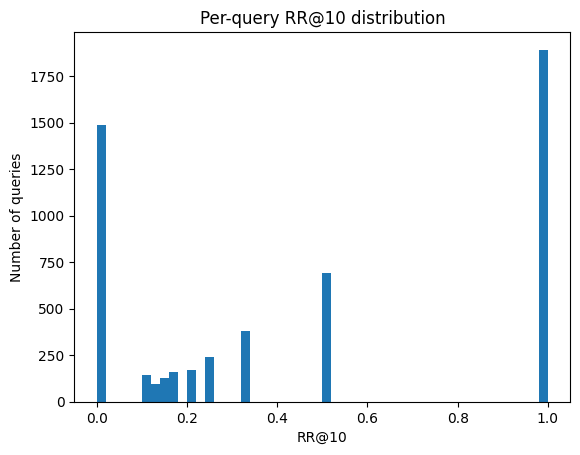

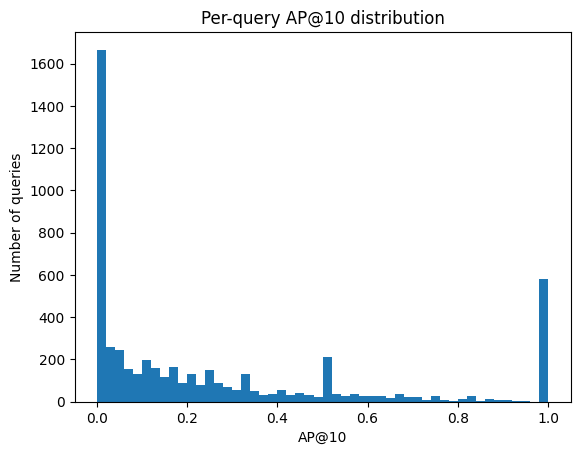

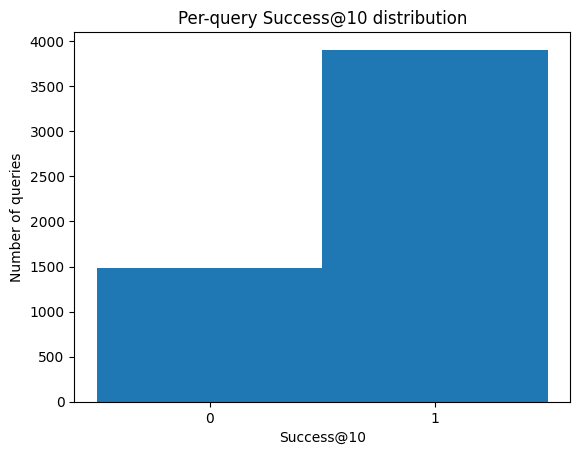

In [44]:
pdf = train_perq_df

# 1) RR@10 distribution
plt.figure()
plt.hist(pdf["RR@10"], bins=50)
plt.title("Per-query RR@10 distribution")
plt.xlabel("RR@10")
plt.ylabel("Number of queries")
plt.show()

# 2) AP@10 distribution
plt.figure()
plt.hist(pdf["AP@10"], bins=50)
plt.title("Per-query AP@10 distribution")
plt.xlabel("AP@10")
plt.ylabel("Number of queries")
plt.show()

# 3) Success@10 distribution (0/1)
plt.figure()
plt.hist(pdf["Success@10"], bins=[-0.5, 0.5, 1.5])
plt.title("Per-query Success@10 distribution")
plt.xlabel("Success@10")
plt.ylabel("Number of queries")
plt.xticks([0, 1])
plt.show()

In [45]:
train_summary

{'MAP@10': 0.2637881308616448,
 'GMAP@10': 0.013458034522939522,
 'MRR@10': 0.4695309669609169,
 'Success@10': 0.7246242345518649,
 'MeanR@50': 0.5537879924614514,
 'MeanR@100': 0.6461506021411665,
 'MeanR@200': 0.7209731245336289,
 'MeanR@500': 0.8048480963167678,
 'MeanR@2000': 0.8559017110748153}

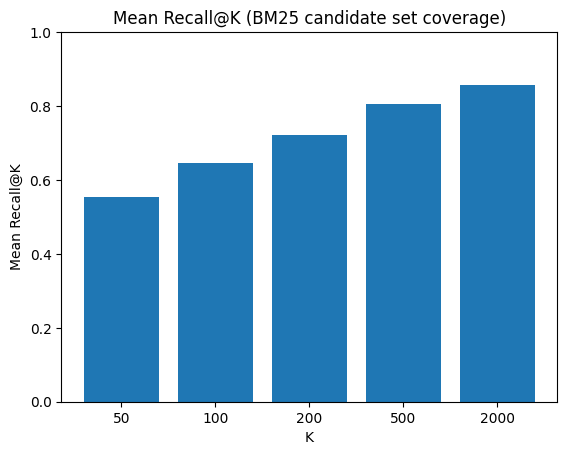

In [52]:
# 4) Mean Recall@K bar chart
Ks = [50, 100, 200, 500,2000]
rec_vals = [train_summary.get(f"MeanR@{k}", 0.0) for k in Ks]

plt.figure()
plt.bar([str(k) for k in Ks], rec_vals)
plt.title("Mean Recall@K (BM25 candidate set coverage)")
plt.xlabel("K")
plt.ylabel("Mean Recall@K")
plt.ylim(0, 1)
plt.show()

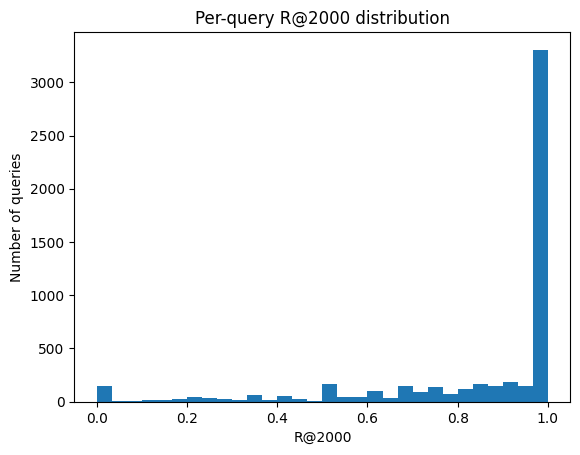

In [53]:
# 5) Optional: per-query Recall@K distributions

col = f"R@2000"
if col in pdf.columns:
    plt.figure()
    plt.hist(pdf[col], bins=30)
    plt.title(f"Per-query {col} distribution")
    plt.xlabel(col)
    plt.ylabel("Number of queries")
    plt.ylim(bottom=0)
    plt.show()

# Build 10% Subset with Gold + Retrieved PMIDs

In [54]:
# Step 1: Collect all gold PMIDs from training data
all_gold_pmids = set()
for pmids in train_gold_map.values():
    all_gold_pmids.update(pmids)

print(f"Total gold PMIDs: {len(all_gold_pmids)}")

# Step 2: Randomly pick 10% of questions (with fixed seed)
random.seed(42)
all_qids = list(train_gold_map.keys())
sample_size = max(1, int(len(all_qids) * 0.1))
sampled_qids = set(random.sample(all_qids, sample_size))

print(f"Total questions: {len(all_qids)}")
print(f"Sampled questions (10%): {len(sampled_qids)}")

# Build sampled questions data for JSON export
sampled_questions = [q for q in train_questions if str(q["id"]) in sampled_qids]
sampled_data = {"questions": sampled_questions}

# Save to example folder
sample_json_path = "../example/training13b_10pct_sample.json"
with open(sample_json_path, "w", encoding="utf-8") as f:
    json.dump(sampled_data, f, indent=2, ensure_ascii=False)

print(f"Saved sampled questions to: {sample_json_path}")

Total gold PMIDs: 49600
Total questions: 5389
Sampled questions (10%): 538
Saved sampled questions to: ../example/training13b_10pct_sample.json


In [55]:
# Step 3: Collect top N=2000 retrieved PMIDs for sampled questions
N_TOP = 2000

retrieved_pool_pmids = set()

# Filter train_res to only sampled questions and get top 2000 per question
sampled_res = train_res[train_res["qid"].isin(sampled_qids)].copy()

for qid in sampled_qids:
    qid_results = sampled_res[sampled_res["qid"] == qid].head(N_TOP)
    retrieved_pmids = qid_results["docno"].astype(str).tolist()
    retrieved_pool_pmids.update(retrieved_pmids)

print(f"Retrieved PMIDs from top {N_TOP} per question: {len(retrieved_pool_pmids)}")

Retrieved PMIDs from top 2000 per question: 471447


In [56]:
# Step 4: Build subset PMIDs = gold ∪ retrieved
subset_pmids = all_gold_pmids | retrieved_pool_pmids

print(f"\nSubset Statistics:")
print(f"  Gold PMIDs: {len(all_gold_pmids)}")
print(f"  Retrieved PMIDs: {len(retrieved_pool_pmids)}")
print(f"  Union (subset): {len(subset_pmids)}")
print(f"  Overlap: {len(all_gold_pmids & retrieved_pool_pmids)}")

# Save subset PMIDs to file
subset_pmids_path = "../example/subset_pmids.txt"
with open(subset_pmids_path, "w") as f:
    for pmid in sorted(subset_pmids):
        f.write(f"{pmid}\n")

print(f"\nSaved subset PMIDs to: {subset_pmids_path}")


Subset Statistics:
  Gold PMIDs: 49600
  Retrieved PMIDs: 471447
  Union (subset): 510958
  Overlap: 10089

Saved subset PMIDs to: ../example/subset_pmids.txt


# check recall 0 ids

In [60]:
# Check if all gold PMIDs are in the index
meta_index = index.getMetaIndex()

gold_in_index = []
gold_not_in_index = []

for pmid in all_gold_pmids:
    try:
        docid = meta_index.getDocument("docno", pmid)
        if docid >= 0:
            gold_in_index.append(pmid)
        else:
            gold_not_in_index.append(pmid)
    except:
        gold_not_in_index.append(pmid)

print(f"Gold PMIDs Coverage:")
print(f"  Total gold PMIDs: {len(all_gold_pmids)}")
print(f"  Found in index: {len(gold_in_index)}")
print(f"  NOT in index: {len(gold_not_in_index)}")
print(f"  Coverage: {100 * len(gold_in_index) / len(all_gold_pmids):.2f}%")

if gold_not_in_index:
    print(f"\nFirst 10 missing gold PMIDs: {gold_not_in_index[:10]}")

Gold PMIDs Coverage:
  Total gold PMIDs: 49600
  Found in index: 49487
  NOT in index: 113
  Coverage: 99.77%

First 10 missing gold PMIDs: ['17364293', '22855961', '22375228', '25401082', '20301779', '23599675', '29676625', '19809570', '20301628', '24212220']


In [62]:
# Check beginSection for missing gold PMIDs
from collections import Counter

# Build a map of PMID -> list of beginSections from snippets
pmid_to_sections = {}

for q in train_questions:
    for snippet in q.get("snippets", []):
        # Extract PMID from document URL
        doc_url = snippet.get("document", "")
        pmid = url_to_pmid(doc_url)
        if pmid:
            section = snippet.get("beginSection", "unknown")
            if pmid not in pmid_to_sections:
                pmid_to_sections[pmid] = []
            pmid_to_sections[pmid].append(section)

# Check beginSection for missing PMIDs
missing_sections = []
for pmid in gold_not_in_index[:100]:  # Check first 100 missing
    sections = pmid_to_sections.get(pmid, [])
    if sections:
        missing_sections.extend(sections)

section_counts = Counter(missing_sections)

print(f"\nbeginSection distribution for missing gold PMIDs:")
print(f"  Total missing PMIDs checked: {min(100, len(gold_not_in_index))}")
print(f"  Total snippets found: {len(missing_sections)}")
print(f"\nSection breakdown:")
for section, count in section_counts.most_common():
    print(f"  {section}: {count} ({100*count/len(missing_sections):.1f}%)")

# Check if any missing PMIDs have only title sections
missing_with_only_title = []
missing_with_abstract = []
missing_with_both = []

for pmid in gold_not_in_index[:100]:
    sections = set(pmid_to_sections.get(pmid, []))
    if sections:
        if sections == {"title"}:
            missing_with_only_title.append(pmid)
        elif "abstract" in sections:
            missing_with_abstract.append(pmid)
        elif sections and "abstract" not in sections:
            missing_with_both.append(pmid)

print(f"\nMissing PMIDs by section type:")
print(f"  Only title: {len(missing_with_only_title)}")
print(f"  Has abstract: {len(missing_with_abstract)}")
print(f"  Other (no abstract): {len(missing_with_both)}")


beginSection distribution for missing gold PMIDs:
  Total missing PMIDs checked: 100
  Total snippets found: 82

Section breakdown:
  abstract: 64 (78.0%)
  title: 14 (17.1%)
  sections.0: 4 (4.9%)

Missing PMIDs by section type:
  Only title: 5
  Has abstract: 47
  Other (no abstract): 4


In [63]:
gold_not_in_index

['17364293',
 '22855961',
 '22375228',
 '25401082',
 '20301779',
 '23599675',
 '29676625',
 '19809570',
 '20301628',
 '24212220',
 '4936649',
 '23986914',
 '20431548',
 '25064957',
 '16570042',
 '7474061',
 '21915623',
 '17462970',
 '19119983',
 '20641567',
 '16451554',
 '15332726',
 '23776883',
 '24132372',
 '26989023',
 '21772710',
 '25383801',
 '10590441',
 '23833797',
 '11339660',
 '24144986',
 '20007090',
 '16477543',
 '34468351',
 '21249951',
 '23741179',
 '27940438',
 '20301427',
 '21413253',
 '37589131',
 '23890950',
 '27399455',
 '21897718',
 '23104528',
 '22527824',
 '15719064',
 '34766984',
 '20301577',
 '23455231',
 '20301293',
 '28976850',
 '20639591',
 '21445329',
 '23376948',
 '20301510',
 '36459075',
 '18941554',
 '20301308',
 '16804530',
 '21284896',
 '23255116',
 '18577682',
 '30242068',
 '32859585',
 '20301585',
 '23658991',
 '37800882',
 '10525005',
 '11428324',
 '20301416',
 '27399411',
 '20301466',
 '21250223',
 '15783264',
 '24305278',
 '18422033',
 '17315395',
 